# Welcome to Colab By Group 6!!! <3

1. LOAD AND COMBINE ALL TRANSACTION FILES

In [ ]:
# ==========================================================
# LOAD ALL TRANSACTION FILES
# ==========================================================

import pandas as pd

df1 = pd.read_csv('/content/Transactions_1.csv')
df2 = pd.read_csv('/content/Transactions_2.csv')
df3 = pd.read_csv('/content/Transactions_3.csv')

transactions = pd.concat(
    [df1, df2, df3],
    ignore_index=True
)

print("Rows:", len(transactions))
print("Columns:", len(transactions.columns))

transactions.head()

Rows: 214861
Columns: 12


/tmp/ipykernel_10143/2159940980.py:8: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv('/content/Transactions_2.csv')


,INDEX,INVOICE_NUMBER,INVOICE_ITEM,DOCUMENT_DATE,CUSTOMER_NUMBER,Main_account,Main_account_name,Main_resposible_employee_name,PRODUCT,Position_type_order_line,GROSS_TURNOVER,AMOUNT
0,33806,124289578,10,2022-10-01,14816.0,14816.0,Customer Group_0,Responsible Employee_0,000000000000100095,ZSV,0.0,1.0
1,65627,124317609,230,2022-10-01,17566.0,17566.0,Customer Group_1,Responsible Employee_1,000000000000100095,ZSV,0.0,1.0
2,65628,124317609,250,2022-10-01,17566.0,17566.0,Customer Group_1,Responsible Employee_1,000000000000100095,ZSV,0.0,0.0
3,65629,124317609,270,2022-10-01,17566.0,17566.0,Customer Group_1,Responsible Employee_1,000000000000100095,ZSV,0.0,1.0
4,65630,124317609,290,2022-10-01,17566.0,17566.0,Customer Group_1,Responsible Employee_1,000000000000100095,ZSV,0.0,1.0


# **PARETO ANALYSIS**

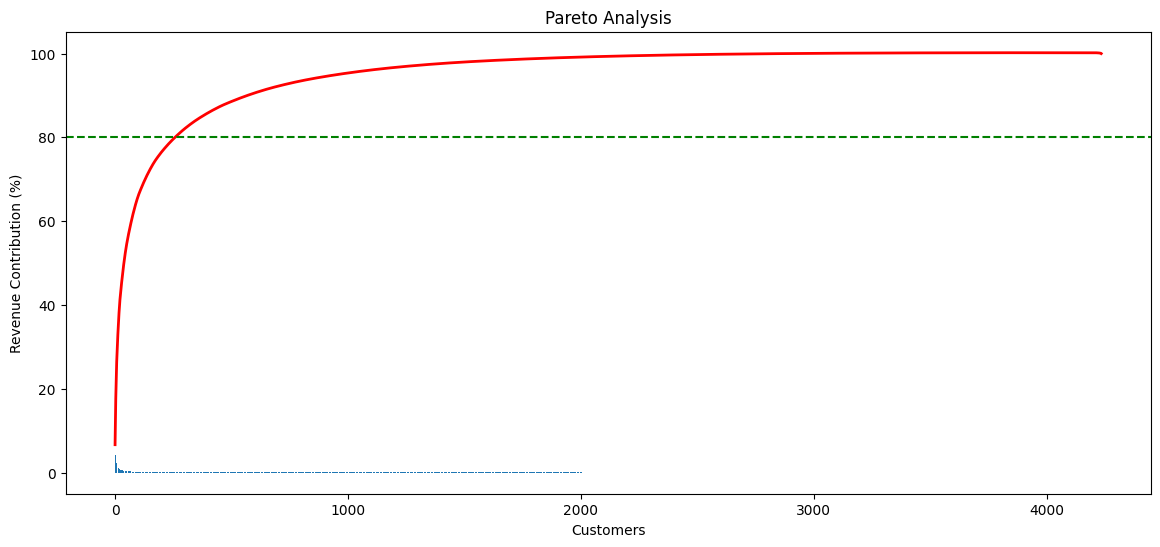

In [ ]:
# ==========================================================
# PARETO ANALYSIS
# ==========================================================

import matplotlib.pyplot as plt

customer_summary = (
    transactions.groupby('Main_account_name')
    ['GROSS_TURNOVER']
    .sum()
    .reset_index()
)

customer_summary = customer_summary.sort_values(
    'GROSS_TURNOVER',
    ascending=False
)

total_revenue = customer_summary[
    'GROSS_TURNOVER'
].sum()

customer_summary['Revenue_Percent'] = (
    customer_summary['GROSS_TURNOVER']
    / total_revenue * 100
)

customer_summary['Cumulative_Percent'] = (
    customer_summary['Revenue_Percent']
    .cumsum()
)

plt.figure(figsize=(14,6))

plt.bar(
    range(len(customer_summary)),
    customer_summary['Revenue_Percent']
)

plt.plot(
    range(len(customer_summary)),
    customer_summary['Cumulative_Percent'],
    color='red',
    linewidth=2
)

plt.axhline(
    y=80,
    color='green',
    linestyle='--'
)

plt.title('Pareto Analysis')
plt.xlabel('Customers')
plt.ylabel('Revenue Contribution (%)')

plt.show()

# **K-Means clustering**

CUSTOMER FEATURES FOR K-MEANS

In [ ]:
# ==========================================================
# CUSTOMER FEATURES
# ==========================================================

customer_features = (
    transactions.groupby('CUSTOMER_NUMBER')
    .agg(
        Revenue=('GROSS_TURNOVER','sum'),
        Frequency=('INVOICE_NUMBER','nunique')
    )
    .reset_index()
)

customer_features.head()

,CUSTOMER_NUMBER,Revenue,Frequency
0,10014.0,46305.7306,23
1,10025.0,82575.3051,71
2,10033.0,157920.1562,175
3,10048.0,1643.3080,11
4,10056.0,30015.7727,25


I) ELBOW METHOD

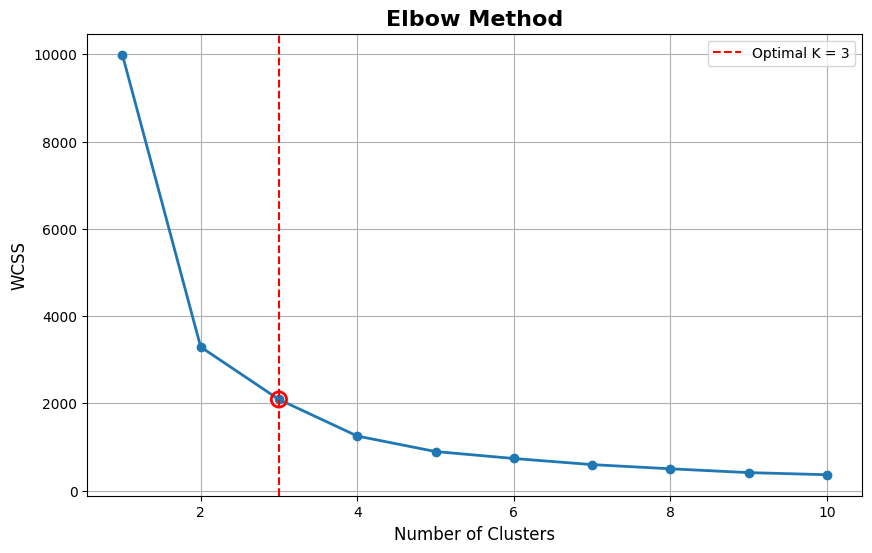


Recommended Number of Clusters = 3


In [ ]:
# ==========================================================
# ELBOW METHOD (PRESENTATION VERSION)
# ==========================================================

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

# Features
X = customer_features[
    ['Revenue', 'Frequency']
]

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Calculate WCSS
wcss = []

K = range(1, 11)

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(
        kmeans.inertia_
    )

# ==========================================================
# CHOOSE ELBOW POINT
# ==========================================================

optimal_k = 3

# ==========================================================
# PLOT
# ==========================================================

plt.figure(figsize=(10,6))

plt.plot(
    K,
    wcss,
    marker='o',
    linewidth=2
)

# Vertical line
plt.axvline(
    x=optimal_k,
    color='red',
    linestyle='--',
    label=f'Optimal K = {optimal_k}'
)

# Highlight point
plt.scatter(
    optimal_k,
    wcss[optimal_k-1],
    s=120,
    facecolors='none',
    edgecolors='red',
    linewidths=2,
    zorder=5
)

plt.title(
    'Elbow Method',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel(
    'Number of Clusters',
    fontsize=12
)

plt.ylabel(
    'WCSS',
    fontsize=12
)

plt.legend()

plt.grid(True)

plt.show()

print(f"\nRecommended Number of Clusters = {optimal_k}")

Columns Found:
['Unnamed: 0', 'Cluster', 'ProdCat1', 'ProdCat2', 'GROSS_TURNOVER', 'INVOICE_NUMBER', 'Main_account_name_number']

Customer Features Created


,Main_account_name_number,Revenue,Frequency
0,100015_Customer Group_2149,21294.0580,6
1,100022_Customer Group_1631,22896.0566,4
2,100027_Customer Group_2392,48166.0658,4
3,100040_Customer Group_2150,35054.3370,3
4,100041_Customer Group_477,294704.4619,12


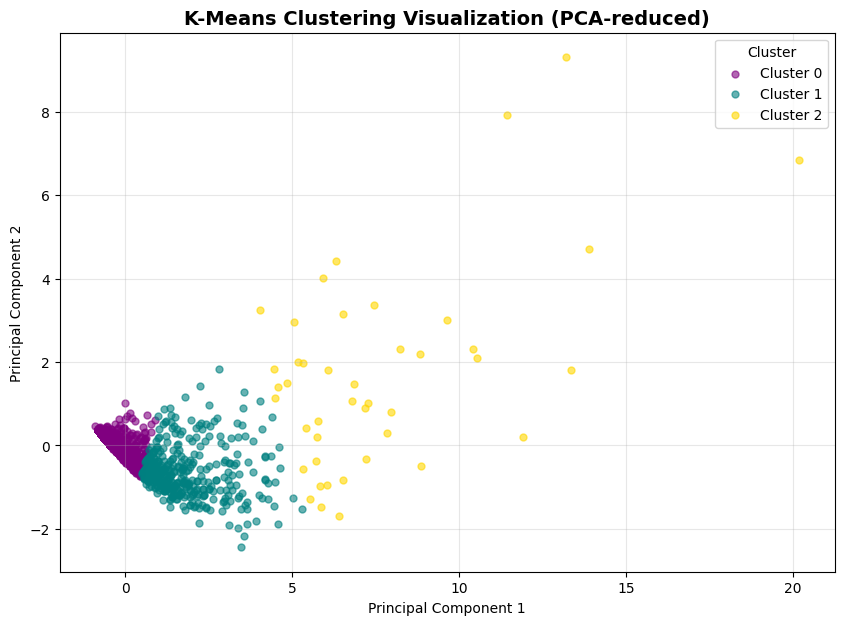



CLUSTER SUMMARY


,Cluster,Customers,Total_Revenue,Avg_Revenue,Avg_Frequency
0,0,2588,1.985522e+08,7.672031e+04,5.848918
1,1,435,4.286848e+08,9.854822e+05,21.200000
2,2,43,2.764776e+08,6.429712e+06,40.860465


In [7]:
# ==========================================================
# K-MEANS CLUSTERING VISUALIZATION (FIXED)
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ----------------------------------------------------------
# LOAD DATA
# ----------------------------------------------------------

df = pd.read_csv('/content/CustSegmentation_Tableau_input_.csv')

print("Columns Found:")
print(df.columns.tolist())

# ----------------------------------------------------------
# CREATE CUSTOMER FEATURES
# ----------------------------------------------------------

customer_features = (
    df.groupby('Main_account_name_number')
      .agg(
          Revenue=('GROSS_TURNOVER', 'sum'),
          Frequency=('INVOICE_NUMBER', 'nunique')
      )
      .reset_index()
)

print("\nCustomer Features Created")
display(customer_features.head())

# ----------------------------------------------------------
# SCALE FEATURES
# ----------------------------------------------------------

X = customer_features[
    ['Revenue', 'Frequency']
]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ----------------------------------------------------------
# K-MEANS CLUSTERING
# ----------------------------------------------------------

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

customer_features['Cluster'] = (
    kmeans.fit_predict(X_scaled)
)

# ----------------------------------------------------------
# PCA REDUCTION
# ----------------------------------------------------------

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# ----------------------------------------------------------
# PCA DATAFRAME
# ----------------------------------------------------------

pca_df = pd.DataFrame({
    'PC1': X_pca[:,0],
    'PC2': X_pca[:,1],
    'Cluster': customer_features['Cluster']
})

# ----------------------------------------------------------
# PCA VISUALIZATION
# ----------------------------------------------------------

plt.figure(figsize=(10,7))

colors = {
    0: 'purple',
    1: 'teal',
    2: 'gold'
}

for cluster in sorted(pca_df['Cluster'].unique()):

    subset = pca_df[
        pca_df['Cluster'] == cluster
    ]

    plt.scatter(
        subset['PC1'],
        subset['PC2'],
        s=25,
        alpha=0.6,
        color=colors[cluster],
        label=f'Cluster {cluster}'
    )

plt.title(
    'K-Means Clustering Visualization (PCA-reduced)',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.legend(title='Cluster')

plt.grid(True, alpha=0.3)

plt.show()

# ----------------------------------------------------------
# CLUSTER SUMMARY
# ----------------------------------------------------------

cluster_summary = (
    customer_features.groupby('Cluster')
      .agg(
          Customers=('Main_account_name_number', 'count'),
          Total_Revenue=('Revenue', 'sum'),
          Avg_Revenue=('Revenue', 'mean'),
          Avg_Frequency=('Frequency', 'mean')
      )
      .reset_index()
)

print("\n")
print("="*80)
print("CLUSTER SUMMARY")
print("="*80)

display(cluster_summary)

II) K-MEANS CLUSTERING

In [ ]:
# ==========================================================
# K-MEANS CLUSTERING
# ==========================================================

from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

customer_features['Cluster'] = (
    kmeans.fit_predict(X_scaled)
)

customer_features.head()

,CUSTOMER_NUMBER,Revenue,Frequency,Cluster
0,10014.0,46305.7306,23,0
1,10025.0,82575.3051,71,0
2,10033.0,157920.1562,175,0
3,10048.0,1643.3080,11,0
4,10056.0,30015.7727,25,0


III) CLUSTER SUMMARY TABLE

In [ ]:
# ==========================================================
# CLUSTER SUMMARY
# ==========================================================

cluster_summary = (
    customer_features.groupby('Cluster')
    .agg(
        Customers=('CUSTOMER_NUMBER','count'),
        Revenue=('Revenue','sum'),
        Avg_Revenue=('Revenue','mean'),
        Avg_Frequency=('Frequency','mean')
    )
    .reset_index()
)

display(cluster_summary)

,Cluster,Customers,Revenue,Avg_Revenue,Avg_Frequency
0,0,4947,8.263179e+07,1.670341e+04,12.114211
1,1,13,4.954694e+07,3.811303e+06,1522.846154
2,2,36,3.472301e+07,9.645281e+05,575.000000


IV) CUSTOMER SEGMENTATION SCATTER PLOT

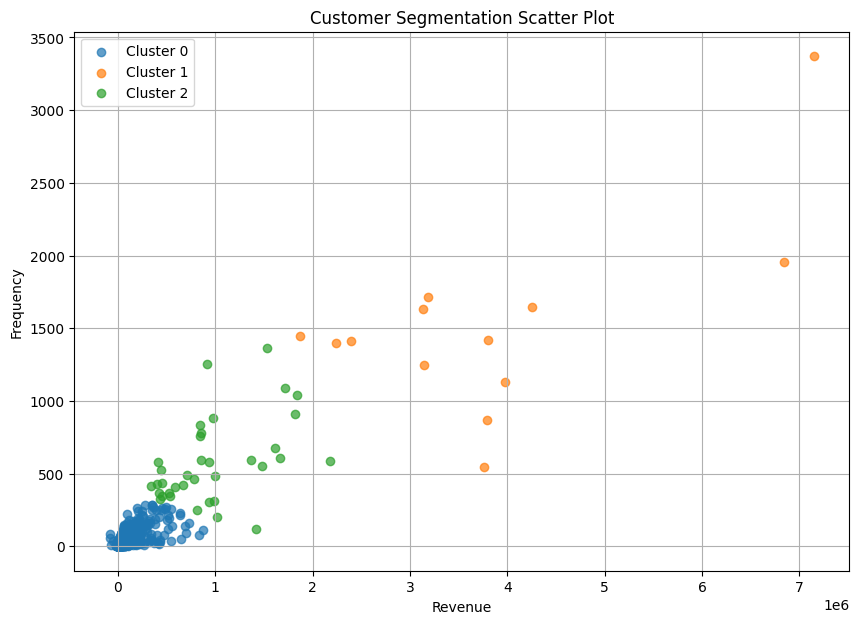

In [ ]:
# ==========================================================
# CUSTOMER SEGMENTATION SCATTER PLOT
# ==========================================================

import matplotlib.pyplot as plt

colors = [
    'red',
    'blue',
    'green',
    'orange'
]

plt.figure(figsize=(10,7))

for cluster in sorted(
    customer_features['Cluster'].unique()
):

    subset = customer_features[
        customer_features['Cluster'] == cluster
    ]

    plt.scatter(
        subset['Revenue'],
        subset['Frequency'],
        alpha=0.7,
        label=f'Cluster {cluster}'
    )

plt.title(
    'Customer Segmentation Scatter Plot'
)

plt.xlabel(
    'Revenue'
)

plt.ylabel(
    'Frequency'
)

plt.legend()

plt.grid(True)

plt.show()

# **Customer Cluster Analysis**

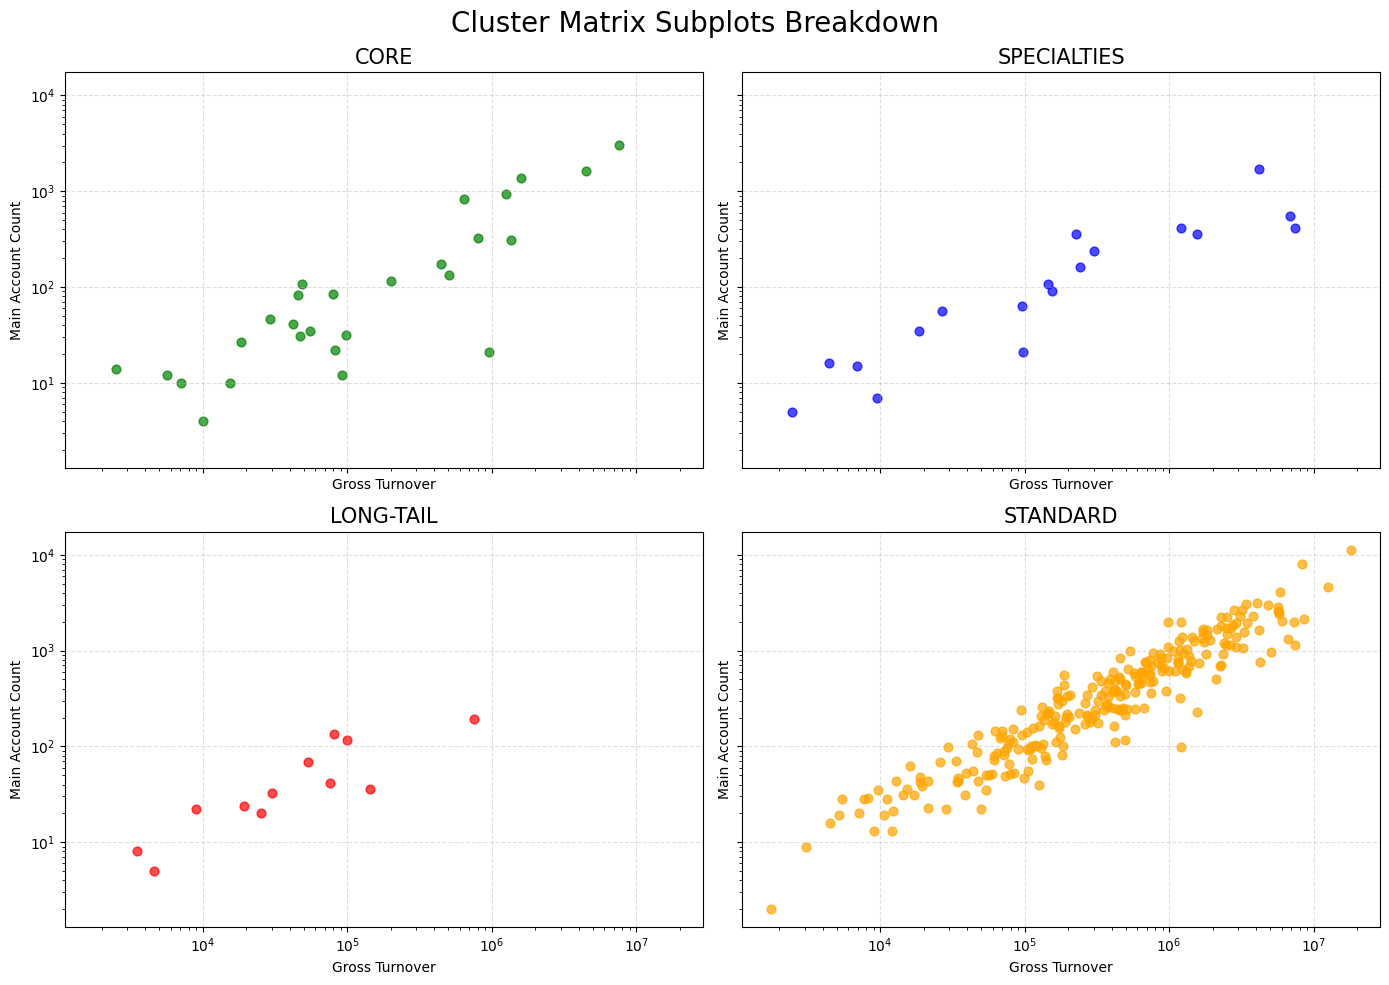

In [ ]:
# ==========================================================
# CLUSTER MATRIX SUBPLOTS BREAKDOWN
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Customer Segmentation File
df = pd.read_csv('/content/CustSegmentation_Tableau_input_.csv')

# ==========================================================
# CREATE CUSTOMER SUMMARY
# ==========================================================

customer_summary = (
    df.groupby(['Main_account_name_number', 'Cluster'])
      .agg({
          'GROSS_TURNOVER': 'sum',
          'INVOICE_NUMBER': 'sum'
      })
      .reset_index()
)

customer_summary.rename(columns={
    'INVOICE_NUMBER': 'Main_Account_Count'
}, inplace=True)

# ==========================================================
# CLUSTER LABELS
# (Adjust if your cluster numbering differs)
# ==========================================================

cluster_names = {
    0: 'CORE',
    1: 'SPECIALTIES',
    2: 'LONG-TAIL',
    3: 'STANDARD'
}

customer_summary['Cluster_Name'] = (
    customer_summary['Cluster']
    .map(cluster_names)
)

# ==========================================================
# PLOT SETTINGS
# ==========================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10),
    sharex=True,
    sharey=True
)

fig.suptitle(
    'Cluster Matrix Subplots Breakdown',
    fontsize=20
)

# Cluster colors
cluster_colors = {
    'CORE': 'green',
    'SPECIALTIES': 'blue',
    'LONG-TAIL': 'red',
    'STANDARD': 'orange'
}

cluster_order = [
    'CORE',
    'SPECIALTIES',
    'LONG-TAIL',
    'STANDARD'
]

# ==========================================================
# CREATE SUBPLOTS
# ==========================================================

for ax, cluster in zip(axes.flatten(), cluster_order):

    subset = customer_summary[
        customer_summary['Cluster_Name'] == cluster
    ]

    ax.scatter(
        subset['GROSS_TURNOVER'],
        subset['Main_Account_Count'],
        color=cluster_colors[cluster],
        alpha=0.7,
        s=40
    )

    ax.set_xscale('log')
    ax.set_yscale('log')

    ax.set_title(cluster, fontsize=15)

    ax.set_xlabel('Gross Turnover')
    ax.set_ylabel('Main Account Count')

    ax.grid(
        True,
        linestyle='--',
        alpha=0.4
    )

plt.tight_layout()

plt.show()

V) LONG-TAIL Analysis

In [ ]:
# ==========================================================
# LONG-TAIL PRODUCTS
# ==========================================================

long_tail = agg_df[
    agg_df["Classification"]=="LONG-TAIL"
].sort_values(
    "turnover",
    ascending=False
)

display(long_tail.head(20))

print("Products:", len(long_tail))
print("Revenue:", f"${long_tail['turnover'].sum():,.2f}")

,ProdCat2,turnover,account_count,Classification
34,Content Marketing Services,310282.9451,126,LONG-TAIL
184,Social Media Advertising,307431.1544,138,LONG-TAIL
169,Retargeting Services,295846.4955,98,LONG-TAIL
8,Analytics and Reporting Services,279544.4574,80,LONG-TAIL
17,Broadband Internet (DSL),277824.9347,138,LONG-TAIL
77,Fixed-Line Telephone Services,264784.4363,224,LONG-TAIL
207,VoIP (Voice Over IP) Services,261619.4996,208,LONG-TAIL
163,Push-to-Talk Services,258678.6659,83,LONG-TAIL
164,Remote Desktop Services,238140.7438,44,LONG-TAIL
171,Routers and Modems,143571.5690,128,LONG-TAIL


Products: 44
Revenue: $4,249,165.06


Interpretation: LONG-TAIL products contribute the least revenue and customer activity.
Although individually small, they may collectively provide portfolio diversity and niche customer support.

CustSegmentation_Tableau_input_.csv > Group by ProdCat2  > Calculate Turnover + Account Count >   Apply Quantile Rules; CORE, STANDARD, SPECIALTIES, LONG-TAIL >  Summary Table

In [ ]:
# ==========================================================
# PRODUCT CATEGORIZATION ANALYSIS TABLE
# ==========================================================

import pandas as pd
from IPython.display import display

# ----------------------------------------------------------
# LOAD DATA
# ----------------------------------------------------------

df = pd.read_csv('/content/CustSegmentation_Tableau_input_.csv')

df = df.rename(columns={
    "GROSS_TURNOVER": "turnover",
    "INVOICE_NUMBER": "account_count"
})

# ----------------------------------------------------------
# AGGREGATE PER PRODUCT
# ----------------------------------------------------------

agg_df = (
    df.groupby("ProdCat2")
      .agg(
          turnover=("turnover","sum"),
          account_count=("account_count","sum")
      )
      .reset_index()
)

# ----------------------------------------------------------
# CLASSIFICATION LOGIC
# ----------------------------------------------------------

turnover_q75 = agg_df["turnover"].quantile(0.75)
turnover_q25 = agg_df["turnover"].quantile(0.25)

account_q75 = agg_df["account_count"].quantile(0.75)
account_q25 = agg_df["account_count"].quantile(0.25)

def classify(row):

    if row["turnover"] >= turnover_q75 and row["account_count"] >= account_q75:
        return "CORE"

    elif row["turnover"] <= turnover_q25 and row["account_count"] <= account_q25:
        return "LONG-TAIL"

    elif row["turnover"] < turnover_q75:
        return "STANDARD"

    else:
        return "SPECIALTIES"

agg_df["Classification"] = agg_df.apply(classify, axis=1)

# ----------------------------------------------------------
# SUMMARY TABLE
# ----------------------------------------------------------

total_products = len(agg_df)
total_turnover = agg_df["turnover"].sum()

summary = (
    agg_df.groupby("Classification")
    .agg(
        Products=("ProdCat2","count"),
        Gross_Turnover=("turnover","sum")
    )
    .reset_index()
)

summary["Product_%"] = (
    summary["Products"] / total_products * 100
)

summary["Revenue_%"] = (
    summary["Gross_Turnover"] / total_turnover * 100
)

order = [
    "CORE",
    "STANDARD",
    "SPECIALTIES",
    "LONG-TAIL"
]

summary["Classification"] = pd.Categorical(
    summary["Classification"],
    categories=order,
    ordered=True
)

summary = summary.sort_values("Classification")

summary["Product_%"] = summary["Product_%"].round(1)
summary["Revenue_%"] = summary["Revenue_%"].round(1)

summary["Gross_Turnover"] = summary["Gross_Turnover"].map(
    lambda x: f"${x:,.2f}"
)

summary = summary.rename(columns={
    "Classification":"Category",
    "Product_%":"Products %",
    "Revenue_%":"Revenue %",
    "Gross_Turnover":"Gross Turnover"
})

print("\n")
print("="*80)
print("PRODUCT CATEGORIZATION ANALYSIS")
print("="*80)

display(summary)



PRODUCT CATEGORIZATION ANALYSIS


,Category,Products,Gross Turnover,Products %,Revenue %
0,CORE,40,"$242,091,559.30",18.3,58.7
3,STANDARD,117,"$97,917,572.47",53.4,23.7
2,SPECIALTIES,15,"$70,800,981.47",6.8,17.2
1,LONG-TAIL,47,"$1,906,997.85",21.5,0.5


ProdCat1 Classification Analysis + Scatter Plot



PRODCAT1 CATEGORIZATION ANALYSIS


,Classification,Categories,Gross_Turnover,Category_%,Revenue_%
0,CORE,4,"$212,083,794.68",19.0%,51.4%
3,STANDARD,10,"$125,197,375.13",47.6%,30.3%
2,SPECIALTIES,2,"$67,418,081.41",9.5%,16.3%
1,LONG-TAIL,5,"$8,017,859.87",23.8%,1.9%


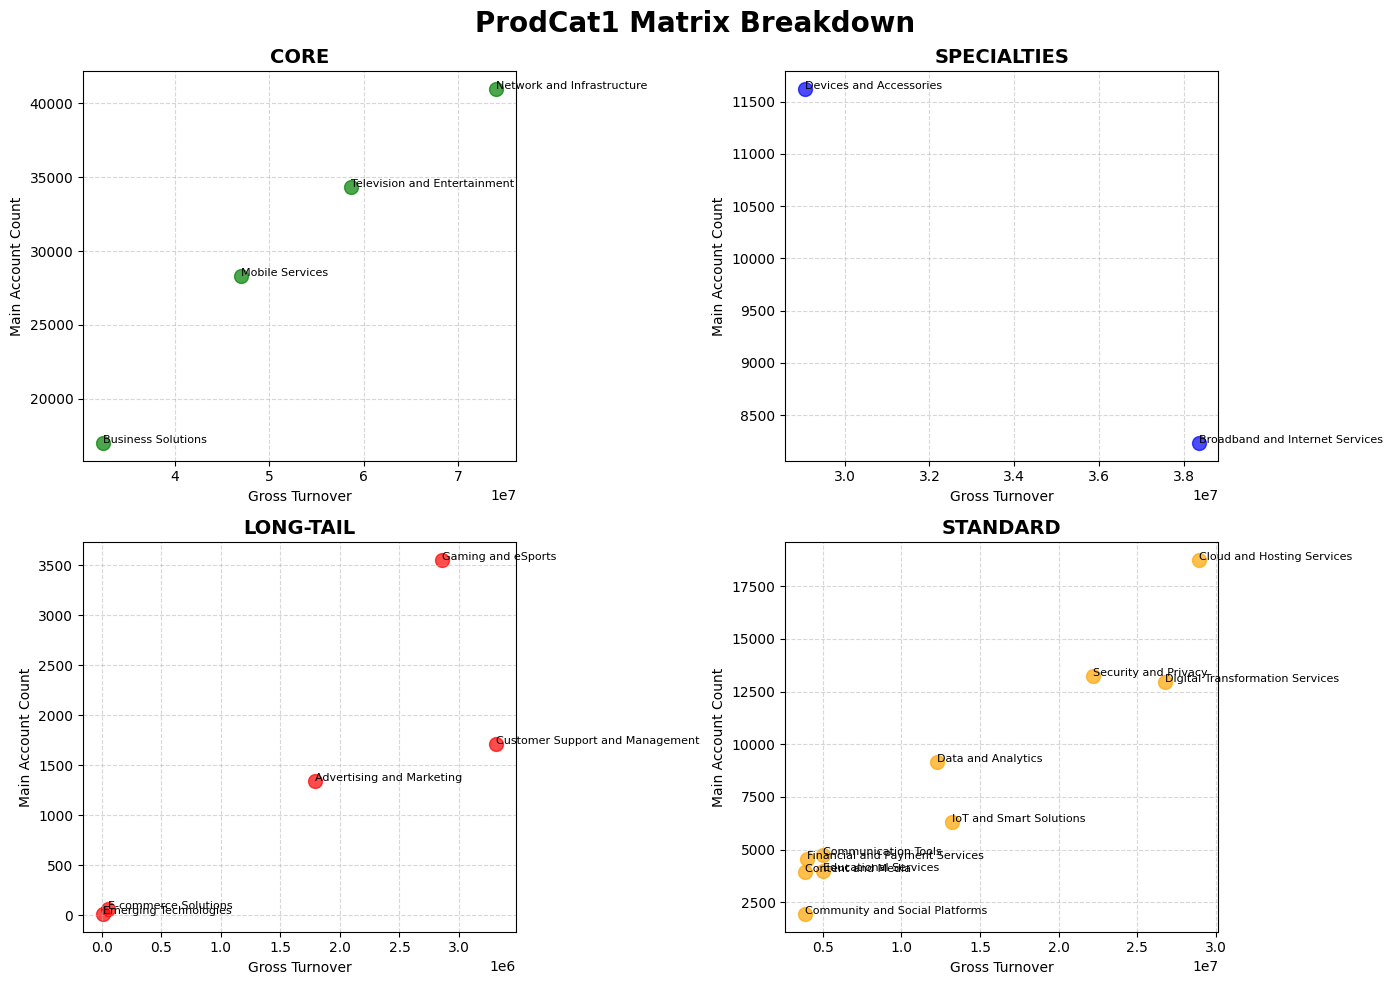

In [ ]:
# ==========================================================
# PRODCAT1 CATEGORIZATION ANALYSIS + SCATTER PLOT
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# --------------------------------------------------
# LOAD DATA
# --------------------------------------------------

df = pd.read_csv("CustSegmentation_Tableau_input_.csv")

df = df.rename(columns={
    "GROSS_TURNOVER": "turnover",
    "INVOICE_NUMBER": "account_count"
})

# --------------------------------------------------
# AGGREGATE BY PRODCAT1
# --------------------------------------------------

agg_df = (
    df.groupby("ProdCat1")
      .agg(
          turnover=("turnover", "sum"),
          account_count=("account_count", "sum")
      )
      .reset_index()
)

# --------------------------------------------------
# CLASSIFICATION LOGIC
# --------------------------------------------------

turnover_q75 = agg_df["turnover"].quantile(0.75)
turnover_q25 = agg_df["turnover"].quantile(0.25)

account_q75 = agg_df["account_count"].quantile(0.75)
account_q25 = agg_df["account_count"].quantile(0.25)

def classify(row):

    if row["turnover"] >= turnover_q75 and row["account_count"] >= account_q75:
        return "CORE"

    elif row["turnover"] <= turnover_q25 and row["account_count"] <= account_q25:
        return "LONG-TAIL"

    elif row["turnover"] < turnover_q75:
        return "STANDARD"

    else:
        return "SPECIALTIES"

agg_df["Classification"] = agg_df.apply(classify, axis=1)

# --------------------------------------------------
# SUMMARY TABLE
# --------------------------------------------------

total_categories = len(agg_df)
total_turnover = agg_df["turnover"].sum()

summary = (
    agg_df.groupby("Classification")
    .agg(
        Categories=("ProdCat1", "count"),
        Gross_Turnover=("turnover", "sum")
    )
    .reset_index()
)

summary["Category_%"] = (
    summary["Categories"] / total_categories * 100
)

summary["Revenue_%"] = (
    summary["Gross_Turnover"] / total_turnover * 100
)

order = [
    "CORE",
    "STANDARD",
    "SPECIALTIES",
    "LONG-TAIL"
]

summary["Classification"] = pd.Categorical(
    summary["Classification"],
    categories=order,
    ordered=True
)

summary = summary.sort_values("Classification")

print("\n")
print("="*80)
print("PRODCAT1 CATEGORIZATION ANALYSIS")
print("="*80)

display(
    summary.style.format({
        "Category_%":"{:.1f}%",
        "Gross_Turnover":"${:,.2f}",
        "Revenue_%":"{:.1f}%"
    })
)

# --------------------------------------------------
# SCATTER PLOT
# --------------------------------------------------

colors = {
    "CORE":"green",
    "SPECIALTIES":"blue",
    "LONG-TAIL":"red",
    "STANDARD":"orange"
}

categories = [
    "CORE",
    "SPECIALTIES",
    "LONG-TAIL",
    "STANDARD"
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14,10)
)

axes = axes.flatten()

for i, cat in enumerate(categories):

    subset = agg_df[
        agg_df["Classification"] == cat
    ]

    axes[i].scatter(
        subset["turnover"],
        subset["account_count"],
        color=colors[cat],
        alpha=0.7,
        s=100
    )

    # Show category names on points
    for _, row in subset.iterrows():
        axes[i].annotate(
            row["ProdCat1"],
            (row["turnover"], row["account_count"]),
            fontsize=8
        )

    axes[i].set_title(
        cat,
        fontsize=14,
        fontweight="bold"
    )

    axes[i].set_xlabel("Gross Turnover")
    axes[i].set_ylabel("Main Account Count")

    axes[i].grid(
        True,
        linestyle="--",
        alpha=0.5
    )

plt.suptitle(
    "ProdCat1 Matrix Breakdown",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

Prodcat 2 Analysis

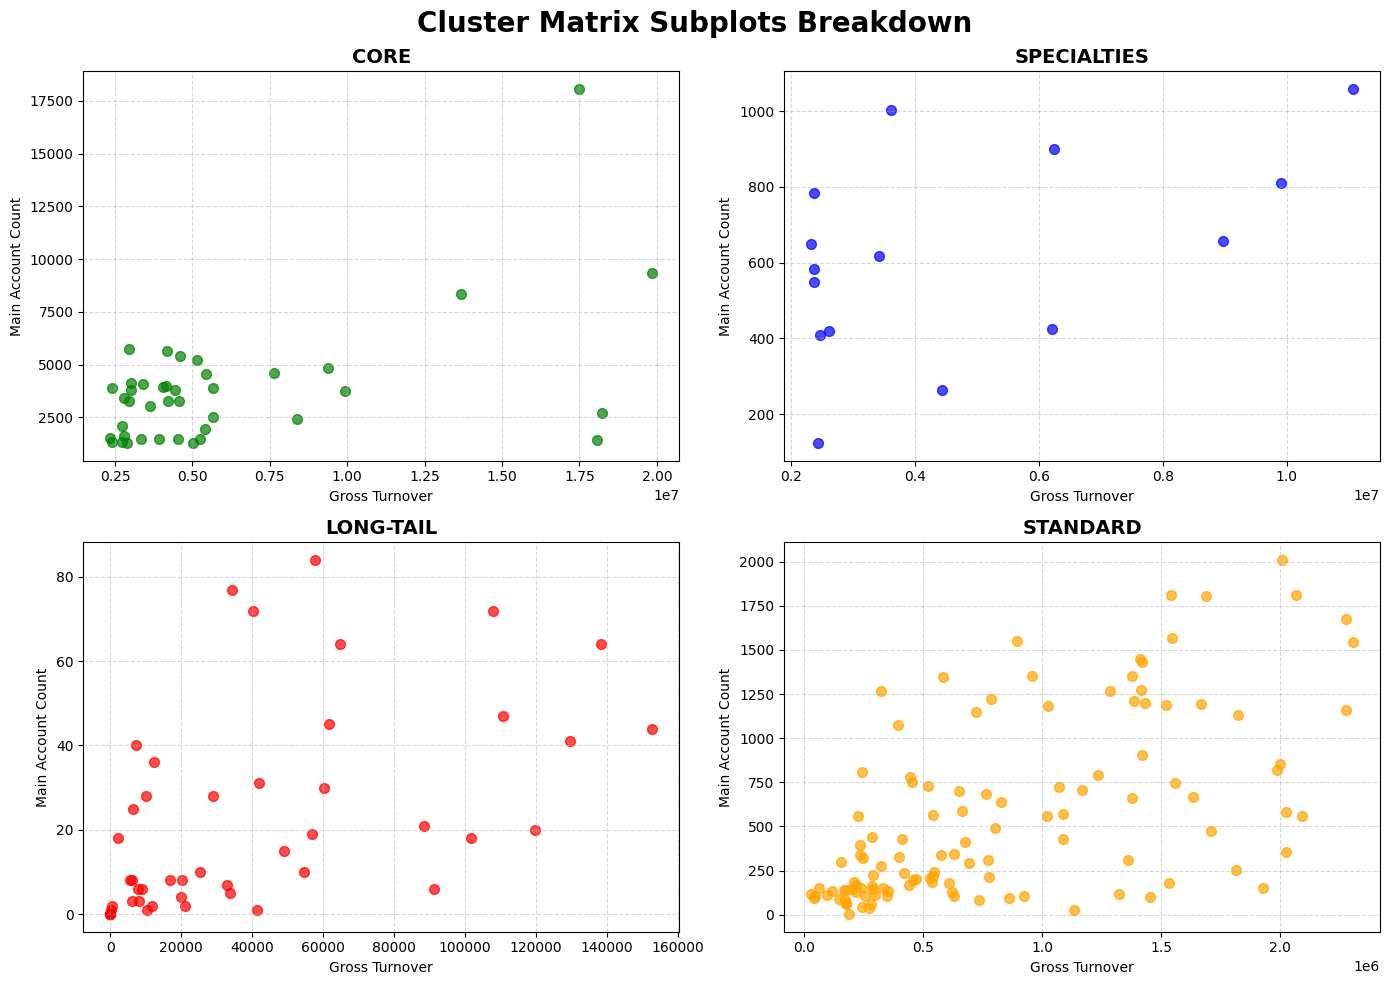

In [ ]:
# --------------------------------------------------
# CLUSTER MATRIX SUBPLOTS
# --------------------------------------------------

colors = {
    "CORE":"green",
    "SPECIALTIES":"blue",
    "LONG-TAIL":"red",
    "STANDARD":"orange"
}

categories = [
    "CORE",
    "SPECIALTIES",
    "LONG-TAIL",
    "STANDARD"
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14,10)
)

axes = axes.flatten()

for i, cat in enumerate(categories):

    subset = agg_df[
        agg_df["Classification"] == cat
    ]

    axes[i].scatter(
        subset["turnover"],
        subset["account_count"],
        color=colors[cat],
        alpha=0.7,
        s=50
    )

    axes[i].set_title(
        cat,
        fontsize=14,
        fontweight='bold'
    )

    axes[i].set_xlabel(
        "Gross Turnover"
    )

    axes[i].set_ylabel(
        "Main Account Count"
    )

    axes[i].grid(
        True,
        linestyle="--",
        alpha=0.5
    )

plt.suptitle(
    "Cluster Matrix Subplots Breakdown",
    fontsize=20,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

# **Save into csv file**

In [ ]:
# ==========================================================
# SHOW ALL CSV FILES IN COLAB
# ==========================================================

import os

print("\nCSV FILES FOUND:\n")

for file in os.listdir('/content'):
    if file.endswith('.csv'):
        print(file)


CSV FILES FOUND:

Transactions_3.csv
CustSegmentation_Tableau_input_.csv
Transactions_1.csv
Transactions_2.csv


In [ ]:
# ==========================================================
# EXPORT CUSTOMER SEGMENTATION
# ==========================================================

customer_features.to_csv(
    'CustSegmentation_Tableau_input_.csv',
    index=False
)

print(
    "Customer segmentation file exported successfully."
)

Customer segmentation file exported successfully.


In [ ]:
# ==========================================================
# CHECK COLUMN NAMES OF EACH CSV
# ==========================================================

import pandas as pd
import os

for file in os.listdir('/content'):

    if file.endswith('.csv'):

        try:

            temp = pd.read_csv(
                f'/content/{file}',
                nrows=2
            )

            print("\n" + "="*80)
            print(file)
            print("="*80)

            print(temp.columns.tolist())

        except Exception as e:

            print(file, "ERROR:", e)


Transactions_3.csv
['INDEX', 'INVOICE_NUMBER', 'INVOICE_ITEM', 'DOCUMENT_DATE', 'CUSTOMER_NUMBER', 'Main_account', 'Main_account_name', 'Main_resposible_employee_name', 'PRODUCT', 'Position_type_order_line', 'GROSS_TURNOVER', 'AMOUNT']

CustSegmentation_Tableau_input_.csv
['Unnamed: 0', 'Cluster', 'ProdCat1', 'ProdCat2', 'GROSS_TURNOVER', 'INVOICE_NUMBER', 'Main_account_name_number']

Transactions_1.csv
['INDEX', 'INVOICE_NUMBER', 'INVOICE_ITEM', 'DOCUMENT_DATE', 'CUSTOMER_NUMBER', 'Main_account', 'Main_account_name', 'Main_resposible_employee_name', 'PRODUCT', 'Position_type_order_line', 'GROSS_TURNOVER', 'AMOUNT']

Transactions_2.csv
['INDEX', 'INVOICE_NUMBER', 'INVOICE_ITEM', 'DOCUMENT_DATE', 'CUSTOMER_NUMBER', 'Main_account', 'Main_account_name', 'Main_resposible_employee_name', 'PRODUCT', 'Position_type_order_line', 'GROSS_TURNOVER', 'AMOUNT']


In [ ]:
# ==========================================================
# AUTO LOAD + VALIDATE + PREPARE DATA FOR CLASSIFICATION
# ==========================================================

import pandas as pd
import os

# ----------------------------------------------------------
# FIND CUSTOMER SEGMENTATION FILE AUTOMATICALLY
# ----------------------------------------------------------

csv_files = [
    f for f in os.listdir('/content')
    if 'CustSegmentation' in f and f.endswith('.csv')
]

print("\n")
print("="*80)
print("SEARCHING FOR CUSTOMER SEGMENTATION FILE")
print("="*80)

print("Files Found:")
print(csv_files)

if len(csv_files) == 0:
    raise FileNotFoundError(
        "No CustSegmentation CSV file found in /content"
    )

file_name = csv_files[0]

print(f"\nLoading File: {file_name}")

# ----------------------------------------------------------
# LOAD FILE
# ----------------------------------------------------------

df = pd.read_csv(f'/content/{file_name}')

# ----------------------------------------------------------
# BASIC INFORMATION
# ----------------------------------------------------------

print("\n")
print("="*80)
print("DATASET INFORMATION")
print("="*80)

print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")

print("\nColumns:")
print(df.columns.tolist())

# ----------------------------------------------------------
# VERIFY REQUIRED COLUMNS
# ----------------------------------------------------------

required_cols = [
    'ProdCat1',
    'ProdCat2',
    'GROSS_TURNOVER',
    'INVOICE_NUMBER'
]

missing_cols = [
    col for col in required_cols
    if col not in df.columns
]

if len(missing_cols) > 0:

    raise ValueError(
        f"Missing Required Columns: {missing_cols}"
    )

print("\n✅ All required columns found.")

# ----------------------------------------------------------
# RENAME COLUMNS
# ----------------------------------------------------------

df = df.rename(columns={
    'GROSS_TURNOVER': 'turnover',
    'INVOICE_NUMBER': 'account_count'
})

# ----------------------------------------------------------
# CREATE PRODCAT2 AGGREGATED DATASET
# ----------------------------------------------------------

agg_df = (
    df.groupby('ProdCat2')
      .agg(
          turnover=('turnover', 'sum'),
          account_count=('account_count', 'sum')
      )
      .reset_index()
)

# ----------------------------------------------------------
# DATA QUALITY CHECK
# ----------------------------------------------------------

zero_turnover = (
    agg_df['turnover'] <= 0
).sum()

zero_accounts = (
    agg_df['account_count'] <= 0
).sum()

print("\n")
print("="*80)
print("PRODCAT2 DATA VALIDATION")
print("="*80)

print(f"Total ProdCat2 Categories: {len(agg_df)}")
print(f"Zero Turnover Categories: {zero_turnover}")
print(f"Zero Account Count Categories: {zero_accounts}")

print("\nSample Data:")
display(agg_df.head(10))

print("\n✅ Data preparation completed successfully.")
print("✅ agg_df is ready for classification.")
print("✅ Ready for CORE / STANDARD / SPECIALTIES / LONG-TAIL analysis.")



SEARCHING FOR CUSTOMER SEGMENTATION FILE
Files Found:
['CustSegmentation_Tableau_input_.csv']

Loading File: CustSegmentation_Tableau_input_.csv


DATASET INFORMATION
Rows: 878,190
Columns: 7

Columns:
['Unnamed: 0', 'Cluster', 'ProdCat1', 'ProdCat2', 'GROSS_TURNOVER', 'INVOICE_NUMBER', 'Main_account_name_number']

✅ All required columns found.


PRODCAT2 DATA VALIDATION
Total ProdCat2 Categories: 219
Zero Turnover Categories: 0
Zero Account Count Categories: 0

Sample Data:


,ProdCat2,turnover,account_count
0,3G Services,1.221965e+05,25
1,4G Services,2.051854e+07,4481
2,5G Services,2.205852e+07,2824
3,5G-Enabled Services,1.286161e+03,4
4,AI-Powered Customer Support,1.107422e+06,501
5,AR Game Development,8.367459e+05,998
6,Access Control Solutions,2.976993e+06,1750
7,Affiliate Marketing Programs,7.840010e+03,4
8,Analytics and Reporting Services,2.795445e+05,80
9,Application Hosting Services,6.030869e+06,7810



✅ Data preparation completed successfully.
✅ agg_df is ready for classification.
✅ Ready for CORE / STANDARD / SPECIALTIES / LONG-TAIL analysis.


1. Create Classification (ProdCat2)

In [ ]:
# ==========================================================
# PRODCAT2 CLASSIFICATION
# ==========================================================

import pandas as pd

df = pd.read_csv("CustSegmentation_Tableau_input_.csv")

df = df.rename(columns={
    "GROSS_TURNOVER":"turnover",
    "INVOICE_NUMBER":"account_count"
})

agg_df = (
    df.groupby("ProdCat2")
      .agg(
          turnover=("turnover","sum"),
          account_count=("account_count","sum")
      )
      .reset_index()
)

turnover_q75 = agg_df["turnover"].quantile(0.75)
turnover_q25 = agg_df["turnover"].quantile(0.25)

account_q75 = agg_df["account_count"].quantile(0.75)
account_q25 = agg_df["account_count"].quantile(0.25)

def classify(row):

    if row["turnover"] >= turnover_q75 and row["account_count"] >= account_q75:
        return "CORE"

    elif row["turnover"] <= turnover_q25 and row["account_count"] <= account_q25:
        return "LONG-TAIL"

    elif row["turnover"] < turnover_q75:
        return "STANDARD"

    else:
        return "SPECIALTIES"

agg_df["Classification"] = agg_df.apply(
    classify,
    axis=1
)

print("Classification Complete")

Classification Complete


2. CORE Analysis

In [ ]:
# ==========================================================
# CORE PRODUCTS
# ==========================================================

core = agg_df[
    agg_df["Classification"]=="CORE"
].sort_values(
    "turnover",
    ascending=False
)

display(core.head(20))

print("Products:", len(core))
print("Revenue:", f"${core['turnover'].sum():,.2f}")

,ProdCat2,turnover,account_count,Classification
121,Mobile Plans (Postpaid),5.579570e+07,4550,CORE
132,Network Infrastructure Services,4.088779e+07,19499,CORE
18,Broadband Internet (Fiber),4.053540e+07,5771,CORE
122,Mobile Plans (Prepaid),3.159964e+07,37251,CORE
212,Wholesale Telecom Services,2.593824e+07,17051,CORE
30,Cloud and Hosting Services,2.359522e+07,3399,CORE
1,4G Services,2.051854e+07,4481,CORE
23,Carrier Services,2.012701e+07,5525,CORE
151,Over-the-Top (OTT) Services,1.732268e+07,7420,CORE
131,Network Equipment Sales,1.692163e+07,10796,CORE


Products: 39
Revenue: $536,714,272.23


Interpretation: CORE products generate the highest revenue and serve the largest number of customers.
These products form the foundation of the business and should receive the highest priority for retention and growth.

3. STANDARD Analysis

In [ ]:
# ==========================================================
# STANDARD PRODUCTS
# ==========================================================

standard = agg_df[
    agg_df["Classification"]=="STANDARD"
].sort_values(
    "turnover",
    ascending=False
)

display(standard.head(20))

print("Products:", len(standard))
print("Revenue:", f"${standard['turnover'].sum():,.2f}")

,ProdCat2,turnover,account_count,Classification
29,Cloud Strategy and Migration,4.985527e+06,3815,STANDARD
170,Robotics Process Automation (RPA),4.973376e+06,1237,STANDARD
191,Technology Advisory,4.787506e+06,289,STANDARD
55,Digital Strategy Development,4.739989e+06,4933,STANDARD
99,IoT Strategy and Consulting,4.714141e+06,1516,STANDARD
98,IoT Solutions Implementation,4.583767e+06,1228,STANDARD
166,Remote Work Solutions,4.495549e+06,1425,STANDARD
70,Enterprise Mobility Management,4.482553e+06,2582,STANDARD
96,Internet of Things (IoT) Solutions,4.353003e+06,372,STANDARD
180,Smart City Solutions,4.345113e+06,4287,STANDARD


Products: 120
Revenue: $226,197,626.51


Interpretation: STANDARD products contribute moderate revenue and customer reach.
These products provide stability and represent the bulk of the product portfolio.

4. SPECIALTIES Analysis

In [ ]:
# ==========================================================
# SPECIALTIES PRODUCTS
# ==========================================================

specialties = agg_df[
    agg_df["Classification"]=="SPECIALTIES"
].sort_values(
    "turnover",
    ascending=False
)

display(specialties.head(20))

print("Products:", len(specialties))
print("Revenue:", f"${specialties['turnover'].sum():,.2f}")

,ProdCat2,turnover,account_count,Classification
71,Enterprise networking equipment,2.524051e+07,2250,SPECIALTIES
2,5G Services,2.205852e+07,2824,SPECIALTIES
188,Sports Subscription Packages,1.675895e+07,1429,SPECIALTIES
198,Unified Communications,1.586648e+07,1648,SPECIALTIES
47,Data Center Equipment - Storage Solutions,1.216779e+07,832,SPECIALTIES
138,News Subscription Packages,9.125666e+06,2138,SPECIALTIES
93,Interactive TV Services,7.683155e+06,2875,SPECIALTIES
189,TV and Entertainment Packages,6.899515e+06,500,SPECIALTIES
19,Business Communication Solutions,6.886728e+06,1201,SPECIALTIES
129,Network Consulting Services,6.706031e+06,2353,SPECIALTIES


Products: 16
Revenue: $163,884,408.47


Interpretation: SPECIALTIES products generate strong revenue but are purchased by a smaller customer base.
These products often target niche markets or specialized customer needs.